In [1]:
import os
from modules_cris import cris_utils as c_utils
import matplotlib.pyplot as plt
import earthaccess
import glob
from datetime import datetime, timedelta
import xarray as xr
import re
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

/home/jturner/miniconda3/envs/spectral_analysis/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
today_date_str = datetime.now().strftime("%Y_%m_%d")

## Plotting CrIS spatially

In [3]:
def download_cris_data(date_start, date_end, lon_west=None, lat_south=None, lon_east=None, lat_north=None, cris_dir="CrIS_data"):
    """
    date_start and date_end format: "2025-06-25"
    coordinate format: -105.31
    """
    #--- Earthaccess docs: https://earthaccess.readthedocs.io/en/latest/quick-start/
    auth = earthaccess.login()

    print("Currently only searches NOAA-20")

    #--- Search for the granule by DOI
    #------ Suomi NPP Normal Spectral Resolution 10.5067/OZZPDWENP2NC
    #------ Suomi NPP Full Spectral Resolution 10.5067/ZCRSHBM5HB23
    #------ NOAA-20 / JPSS-1 Full Spectral Resolution 10.5067/LVEKYTNSRNKP
    #------ NOAA-21 / JPSS-2 Full Spectral Resolution 
    results = earthaccess.search_data(
        doi='10.5067/LVEKYTNSRNKP',
        temporal=(date_start, date_end), 
        # bounding_box=(lon_west, lat_south, lon_east, lat_north)
    )
    os.makedirs(f"{cris_dir}", exist_ok=True)
    files = earthaccess.download(results, cris_dir)
    print(f"{len(files)} downloaded.")
    return files

In [4]:
cris_dir = "data/cris/from_earthaccess"
cris_date = "20260306" #YYYYMMDD
cris_pattern = os.path.join(cris_dir, f"SNDR.J1.CRIS.{cris_date}*")

cris_files = glob.glob(cris_pattern)
cris_files.sort() 
print(f"{len(cris_files)} CrIS files found...")
if not cris_files:
    print("CrIS files not found, downloading...")
    date_obj = datetime.strptime(cris_date, "%Y%m%d")
    sel_day_formatted = date_obj.strftime("%Y-%m-%d")
    next_day_formatted = (date_obj + timedelta(days=1)).strftime("%Y-%m-%d")
    cris_files = download_cris_data(sel_day_formatted, next_day_formatted, cris_dir=cris_dir)

237 CrIS files found...


In [5]:
def create_cris_da(cris_files, wnum_sel):
    print("Creating CrIS dataset...")

    ds = xr.open_mfdataset(
        cris_files,
        combine="nested",
        concat_dim="atrack")

    ds_sel = ds.sel(fov=0, wnum_lw=wnum_sel)
    da_cris = ds_sel['rad_lw']

    start_dt = extract_datetime_from_filename_cris(cris_files[0])
    end_dt   = extract_datetime_from_filename_cris(cris_files[-1])
    if start_dt and end_dt:
        datetime_str = f"{start_dt} - {end_dt}"
    else:
        datetime_str = "Unknown - File format unexpected."

    return da_cris, datetime_str

def extract_datetime_from_filename_cris(filename):
    match = re.search(r'CRIS.(\d{8})T(\d{4})', filename)

    if not match:
        return None

    date_part = match.group(1)
    time_part = match.group(2)

    date_formatted = f"{date_part[:4]}-{date_part[4:6]}-{date_part[6:]}"
    time_formatted = f"{time_part[:2]}:{time_part[2:4]}"

    return f"{date_formatted} {time_formatted}"

In [6]:
cris_files_sample = cris_files[:12]
print(f"Using {len(cris_files_sample)}/{len(cris_files)} of the files...")

da_cris, datetime_str = create_cris_da(cris_files_sample, wnum_sel=750)

Using 12/237 of the files...
Creating CrIS dataset...


Plotting CrIS radiance (750.0 cm-1)...


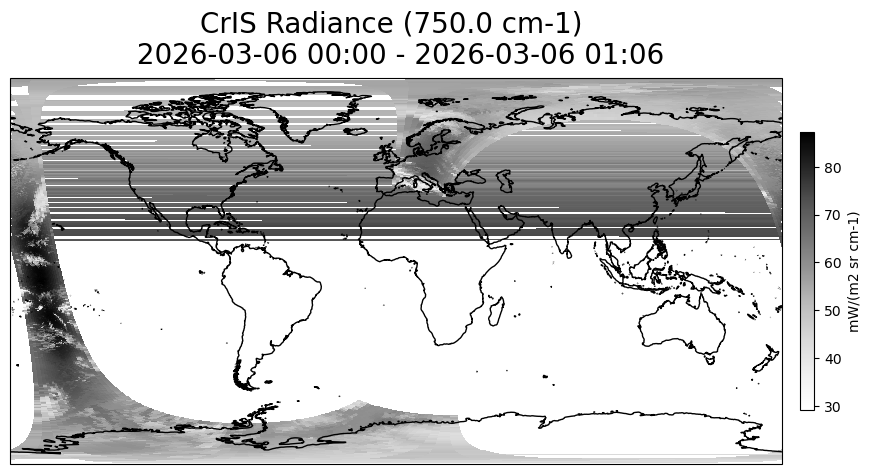

In [7]:
wnum_sel = da_cris['wnum_lw'].values
print(f"Plotting CrIS radiance ({wnum_sel} cm-1)...")
projection=ccrs.PlateCarree(central_longitude=0)
fig,ax=plt.subplots(1, figsize=(12,12),subplot_kw={'projection': projection})

c = ax.pcolormesh(da_cris['lon'], da_cris['lat'], da_cris, cmap='Greys', shading='auto')
# sc = ax.scatter(
#     da_cris['lon'],
#     da_cris['lat'],
#     c=da_cris,
#     cmap="Blues_r",
#     s=1,
#     marker="s",
#     linewidths=0,
#     vmin=50,
#     vmax=66,
#     transform=ccrs.PlateCarree()
# )

ax.coastlines(resolution='50m', color='black', linewidth=1)
ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())

cbar = plt.colorbar(c, ax=ax, orientation='vertical', pad=0.02, shrink=0.3)
cbar.set_label("mW/(m2 sr cm-1)")
ax.set_title(f"CrIS Radiance ({wnum_sel} cm-1) \n {datetime_str}", fontsize=20, pad=10)

plt.savefig(f"plots/{today_date_str}_cris_spatial.png",
            dpi=200, bbox_inches='tight')
plt.show()

## Plotting spectra from a point

In [8]:
cris_dir = "data/cris/from_earthaccess/"
cris_file = "SNDR.J1.CRIS.20260305T2354.m06.g240.L1B.std.v03_08.G.260306074817.nc"
file_path = os.path.join(cris_dir, cris_file)

In [9]:
cris_target_lat = 40
cris_target_lon = -67.75

ds = c_utils.open_cris_data(file_path)
ds = c_utils.isolate_target_point(ds, target_lat=cris_target_lat, target_lon=cris_target_lon)
df_cris = c_utils.get_brightness_temperature(ds)
wl_1, Tb_1 = df_cris["Wavelength (um)"], df_cris["Brightness Temperature (K)"]

Using lat/lon of -60.31, -17.53, fov of 2


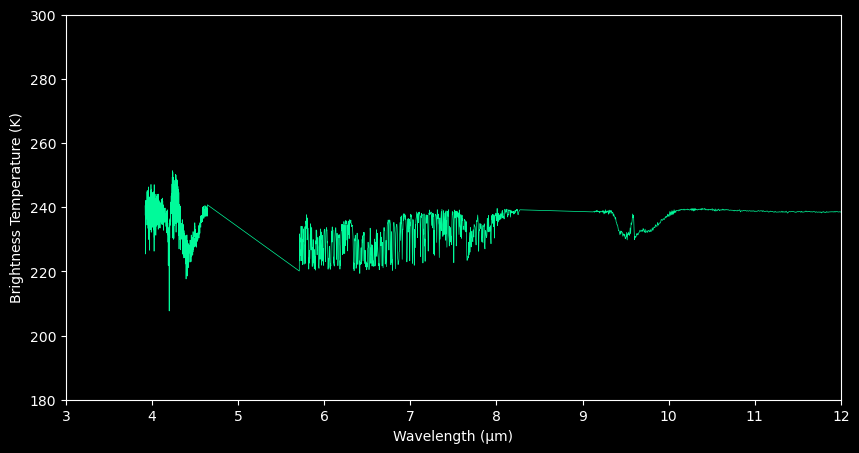

In [10]:
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_facecolor('black')

ax.plot(wl_1, Tb_1, 
        color="#00FA9A", 
        linewidth=0.5)
ax.set_xlim((3,12))
ax.set_ylim((180,300))

ax.set_xlabel("Wavelength (μm)")
ax.set_ylabel("Brightness Temperature (K)")

plt.savefig(f"plots/{today_date_str}_cris_spectra.png", dpi=200, bbox_inches='tight')
plt.show()